# Option Vega-Neutral Pair Trading Walkthrough
This notebook mirrors the equity pairs workflow but swaps in options and vega-balanced sizing using the utilities in `src/options/`. Use it as a living playbook: explore candidates, price contracts, run a backtest, then wire signals into the multi-leg executor.

## 1. Prerequisites
- Python 3.10+ virtualenv activated
- `pip install -r ../requirements.txt` (ensures `alpaca-py`, `py_vollib_vectorized`, `scipy`)
- `.env` with Alpaca Paper API keys if you want live data; otherwise the notebook falls back to synthetic fixtures so it can run offline.

In [9]:
# Standard libraries
import json
import math
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

from src.options.data_handler import OptionDataHandler
from src.options.multileg import MultiLegExecutionHelper
from src.strategies.option_pairs import OptionPairsStrategy

pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8")
np.random.seed(42)
DATA_DIR = Path("../data")
PAIRS_PATH = DATA_DIR / "cointegrated_pairs.csv"

## 2. Pick a cointegrated pair
Load the CSV generated by the `0_find_pairs.ipynb` notebook (or drop in your own symbol list). We'll default to `MSFT`/`AAPL` if the file is missing.

In [10]:
DEFAULT_PAIR = ("MSFT", "AAPL")

# Try to find a valid pair from the CSV that actually has data
symbol_a, symbol_b = DEFAULT_PAIR

if PAIRS_PATH.exists():
    pairs_df = pd.read_csv(PAIRS_PATH)
    display(pairs_df.head())
    
    # Check if we have Alpaca keys to validate symbols
    use_alpaca_check = bool(os.environ.get("APCA_API_KEY_ID"))
    valid_pair_found = False
    
    if use_alpaca_check:
        print("Alpaca keys found. Validating pairs against live API...")
        try:
            from src.data_handler import DataHandler
            # Initialize a temporary handler just for validation
            validator = DataHandler()
            
            for index, row in pairs_df.iterrows():
                s_a = str(row["symbol_a"]).upper()
                s_b = str(row["symbol_b"]).upper()
                
                # Quick check: can we get a latest bar or historical data?
                # We use get_latest_bar as a proxy for "is this symbol alive/tradable"
                bar_a = validator.get_latest_bar(s_a)
                bar_b = validator.get_latest_bar(s_b)
                
                if bar_a and bar_b:
                    symbol_a = s_a
                    symbol_b = s_b
                    valid_pair_found = True
                    print(f"Found valid live pair: {symbol_a} / {symbol_b}")
                    break
                else:
                    missing = []
                    if not bar_a: missing.append(s_a)
                    if not bar_b: missing.append(s_b)
                    print(f"Skipping {s_a}/{s_b}: No data for {', '.join(missing)}")
                    
        except Exception as e:
            print(f"Validation failed (using default/first pair): {e}")
            
    if not valid_pair_found and not pairs_df.empty:
        # Fallback to first pair if validation failed or no keys
        print("No valid live pair found or validation skipped. Using first pair from CSV.")
        symbol_a = str(pairs_df.iloc[0]["symbol_a"]).upper()
        symbol_b = str(pairs_df.iloc[0]["symbol_b"]).upper()
else:
    print("Cointegration file not found; falling back to default pair", DEFAULT_PAIR)

print(f"Selected pair: {symbol_a} vs {symbol_b}")

,symbol_a,symbol_b,hedge_ratio,p_value
0,BLK,MS,7.911508,0.042965
1,AXP,BAC,3.596525,0.032571
2,AXP,PNC,0.779144,0.011383
3,AXP,FITB,3.193734,0.013758
4,V,MA,0.535062,0.042191


Alpaca keys found. Validating pairs against live API...
Data Handler (alpaca-py) initialized.
Found valid live pair: BLK / MS
Selected pair: BLK vs MS
Found valid live pair: BLK / MS
Selected pair: BLK vs MS


## 3. Build a data handler (offline-friendly)
`OptionPairsStrategy` expects the same `DataHandler` interface used by equities. To keep the notebook runnable without hitting Alpaca, we'll create a synthetic handler that mimics `get_historical_bars`/`get_latest_bar` and optionally swap in the real one if your API keys are available.

In [11]:
DATES = pd.date_range(end=pd.Timestamp.today().normalize(), periods=900, freq="B")
base = np.linspace(90, 130, len(DATES))
noise_a = np.random.normal(scale=1.5, size=len(DATES))
noise_b = np.random.normal(scale=1.0, size=len(DATES))
prices_a = base + noise_a
prices_b = base * 0.92 + noise_b

synthetic_frames = {
    symbol_a: pd.DataFrame({"close": prices_a}, index=DATES),
    symbol_b: pd.DataFrame({"close": prices_b}, index=DATES),
}

def _ensure_synthetic(symbol: str) -> pd.DataFrame:
    if symbol in synthetic_frames:
        return synthetic_frames[symbol]
    shifted = base * (0.85 + 0.3 * np.random.rand())
    noise = np.random.normal(scale=1.2, size=len(DATES))
    synthetic_frames[symbol] = pd.DataFrame({"close": shifted + noise}, index=DATES)
    return synthetic_frames[symbol]

import importlib
import src.data_handler
importlib.reload(src.data_handler)

@dataclass
class NotebookDataHandler:
    use_alpaca: bool = bool(os.environ.get("APCA_API_KEY_ID"))

    def __post_init__(self):
        self.real_handler = None
        if self.use_alpaca:
            print(f"Alpaca keys detected. Initializing connection...")
            from src.data_handler import DataHandler
            try:
                self.real_handler = DataHandler()
                print("Successfully connected to Alpaca.")
            except Exception as exc:
                print(f"Failed to connect to Alpaca: {exc}")
                print("Falling back to synthetic data.")
                self.real_handler = None
                self.use_alpaca = False
        else:
            print("No Alpaca keys found in environment variables.")
            print("Ensure your .env file is correct and re-run the notebook.")
            print("Falling back to synthetic data.")

    def get_historical_bars(self, symbols, timeframe, start, end=None):
        if self.real_handler:
            return self.real_handler.get_historical_bars(symbols, timeframe, start, end)
        return {sym: _ensure_synthetic(sym) for sym in symbols}

    def get_latest_bar(self, symbol):
        if self.real_handler:
            bar = self.real_handler.get_latest_bar(symbol)
            if bar is None:
                print(f"Warning: Could not fetch latest bar for {symbol} from Alpaca.")
            return bar
        df = _ensure_synthetic(symbol)
        return {"close": float(df.iloc[-1]["close"])}

data_handler = NotebookDataHandler()
print(f"Active Data Handler: {'ALPACA (LIVE/PAPER)' if data_handler.use_alpaca else 'SYNTHETIC (OFFLINE)'}")

Alpaca keys detected. Initializing connection...
Data Handler (alpaca-py) initialized.
Successfully connected to Alpaca.
Active Data Handler: ALPACA (LIVE/PAPER)


## 4. Option snapshot & greeks
`OptionDataHandler` wraps our data source and combines it with the `GreeksCalculator` so we can request the contract closest to a target delta. We'll inspect both legs, then size the hedge by vega.

In [12]:
option_data = OptionDataHandler(data_handler)

print(f"Fetching snapshots for {symbol_a} and {symbol_b}...")

snapshot_a = option_data.get_option_snapshot(
    symbol=symbol_a,
    option_type="call",
    target_delta=0.45,
    days_to_expiry=30,
 )
snapshot_b = option_data.get_option_snapshot(
    symbol=symbol_b,
    option_type="call",
    target_delta=0.45,
    days_to_expiry=30,
 )

if snapshot_a is None:
    print(f"Failed to get snapshot for {symbol_a}")
if snapshot_b is None:
    print(f"Failed to get snapshot for {symbol_b}")

if snapshot_a is None or snapshot_b is None:
    raise RuntimeError(
        "Option snapshot unavailable. Ensure Alpaca keys are loaded and symbols have recent data.",
    )

print("Leg A snapshot:")
display(snapshot_a)
print("\nLeg B snapshot:")
display(snapshot_b)
vega_a = option_data.greeks.metrics(
    option_type="call",
    spot=snapshot_a.spot,
    strike=snapshot_a.strike,
    ttm=snapshot_a.ttm,
    vol=snapshot_a.implied_vol,
 )["vega"]
vega_ratio = vega_a / max(snapshot_b.vega, 1e-6)
print(f"Vega ratio (A/B): {vega_ratio:.2f}")

Fetching snapshots for BLK and MS...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Leg A snapshot:
Submitting data request to Alpaca...
Leg A snapshot:


OptionSnapshot(symbol='BLK', option_type='call', strike=1074.6317889404295, expiration='2025-12-19', ttm=0.11904761904761904, spot=1061.84, implied_vol=0.19576765802996574, price=23.372186177381025, delta=0.44991122595833627, vega=145.00678701662102, gamma=0.005518340669028419, theta=-123.77169968925672)


Leg B snapshot:


OptionSnapshot(symbol='MS', option_type='call', strike=166.1095245666504, expiration='2025-12-19', ttm=0.11904761904761904, spot=163.86, implied_vol=0.22023328294555064, price=4.038152383995552, delta=0.4499547146284513, vega=22.37732674930683, gamma=0.03178766560101332, theta=-21.395489232439772)

Vega ratio (A/B): 6.48


## 5. Configure `OptionPairsStrategy` and run a backtest
We'll iterate through **all** pairs in the CSV, run the backtest for each, and select the best performing pair (highest Sharpe ratio) to visualize below.

In [13]:
results = []
print(f"Backtesting {len(pairs_df)} pairs from CSV...")

for index, row in pairs_df.iterrows():
    s_a = str(row["symbol_a"]).upper()
    s_b = str(row["symbol_b"]).upper()
    
    print(f"Testing {s_a} vs {s_b}...", end=" ")
    
    try:
        test_strategy = OptionPairsStrategy(
            data_handler=data_handler,
            execution_handler=None,
            symbol_a=s_a,
            symbol_b=s_b,
            option_type="call",
            target_delta=0.45,
            days_to_expiry=30,
            entry_threshold=0.5,
            exit_threshold=0.0,
            contracts=1,
            lookback_days=60,
            timeframe="1H",
            auto_execute=False,
            option_data_handler=option_data,
        )
        
        test_summary = test_strategy.run_backtest(
            start_date=(DATES[0]).date().isoformat(),
            end_date=(DATES[-1]).date().isoformat(),
            timeframe="1D",
        )
        
        sharpe = test_summary.get("sharpe", -999)
        total_return = test_summary.get("strategy_return", -999)
        
        # Basic validation: ignore flat/zero results if that indicates failure
        if total_return == 0.0 and sharpe == 0.0:
             print("Skipping (flat result)")
             continue

        results.append({
            "symbol_a": s_a,
            "symbol_b": s_b,
            "sharpe": sharpe,
            "return": total_return,
            "strategy": test_strategy,
            "summary": test_summary
        })
        print(f"Sharpe: {sharpe:.2f}, Return: {total_return:.2%}")
        
    except Exception as e:
        print(f"Failed: {e}")

if not results:
    raise RuntimeError("No pairs could be successfully backtested.")

# Sort by Total Return descending
results.sort(key=lambda x: x["return"], reverse=True)
best_result = results[0]

print("\n--- Backtest Results (Ranked by Return) ---")
results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['strategy', 'summary']} for r in results])
display(results_df)

print(f"\nBest Pair Selected: {best_result['symbol_a']}/{best_result['symbol_b']} (Return: {best_result['return']:.2%}, Sharpe: {best_result['sharpe']:.2f})")

# Update global variables so downstream cells use the best pair
strategy = best_result["strategy"]
summary = best_result["summary"]
symbol_a = best_result["symbol_a"]
symbol_b = best_result["symbol_b"]

summary

Backtesting 18 pairs from CSV...
Testing BLK vs MS... BaseStrategy initialized with symbols: ['BLK', 'MS']
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Sharpe: 0.71, Return: 11.56%
Testing AXP vs BAC... BaseStrategy initialized with symbols: ['AXP', 'BAC']
Submitting data request to Alpaca...
Sharpe: 0.71, Return: 11.56%
Testing AXP vs BAC... BaseStrategy initialized with symbols: ['AXP', 'BAC']
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data r

,symbol_a,symbol_b,sharpe,return
0,V,MS,0.568228,2.003805
1,V,GS,0.563607,0.824985
2,MA,MS,0.676609,0.472985
3,BLK,MS,0.711062,0.115576
4,AXP,PNC,0.789066,0.006400
5,AXP,FITB,0.755147,0.002826
6,AXP,BAC,1.400596,0.002306
7,TFC,ZION,1.076320,0.001907
8,PNC,FITB,1.070910,0.001568
9,MS,DOV,1.166269,0.001128



Best Pair Selected: V/MS (Return: 200.38%, Sharpe: 0.57)


{'num_trades': 25,
 'open_trades': 1,
 'total_pnl': np.float64(20038.045335284085),
 'win_rate': 0.8,
 'strategy_return': np.float64(2.0038045335284087),
 'sharpe': 0.5682282094766774,
 'max_drawdown': 0.0019519119742646973,
 'equity_curve': timestamp
 2022-10-11 04:00:00    10000.000000
 2022-10-12 04:00:00    10000.000000
 2022-10-13 04:00:00    10000.000000
 2022-10-14 04:00:00    10000.000000
 2022-10-17 04:00:00    10000.000000
                            ...     
 2025-11-12 05:00:00    30038.045335
 2025-11-13 05:00:00    30038.045335
 2025-11-14 05:00:00    30038.045335
 2025-11-17 05:00:00    30038.045335
 2025-11-18 05:00:00    30038.045335
 Length: 780, dtype: float64,
 'trades': [{'timestamp': '2022-11-11 05:00:00',
   'direction': 'long',
   'entry_a': np.float64(8.216918384163459e-21),
   'entry_b': np.float64(1.6297783971427823e-14),
   'vega_ratio': np.float64(0.1),
   'exit_a': np.float64(1.8963543112979603e-18),
   'exit_b': np.float64(1.896242489074934e-15),
   'pnl'

Submitting data request to Alpaca...


strategy_return     200.38%
benchmark_return     84.51%
excess_return       115.87%
sharpe               56.82%
max_drawdown          0.20%
dtype: object

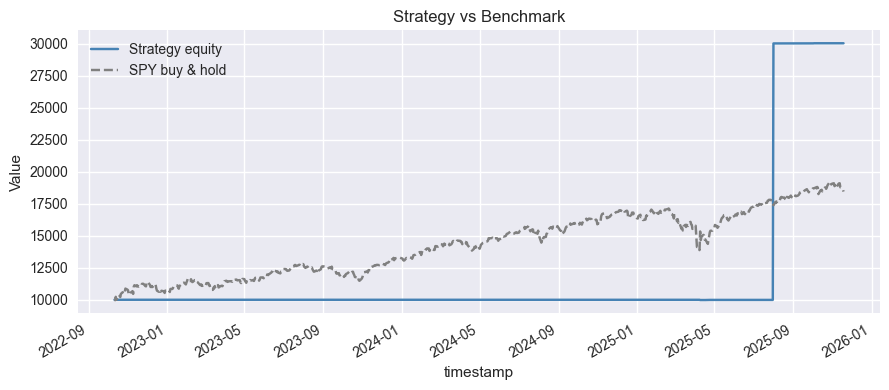

In [14]:
# Benchmark comparison (run after the backtest cell)
BENCHMARK_SYMBOL = "SPY"
benchmark_data = data_handler.get_historical_bars(
    [BENCHMARK_SYMBOL],
    "1D",
    start=(DATES[0]).date().isoformat(),
    end=(DATES[-1]).date().isoformat(),
)

bench_df = (benchmark_data or {}).get(BENCHMARK_SYMBOL)
if bench_df is None or bench_df.empty:
    print(f"No benchmark data for {BENCHMARK_SYMBOL}; skipping comparison.")
else:
    bench_series = bench_df["close"].astype(float)
    bench_series.index = pd.to_datetime(bench_series.index).tz_localize(None)
    bench_series = bench_series.sort_index()
    bench_series = bench_series.loc[
        (bench_series.index >= summary["equity_curve"].index[0])
        & (bench_series.index <= summary["equity_curve"].index[-1])
    ]
    benchmark_return = float(bench_series.iloc[-1] / bench_series.iloc[0] - 1)
    summary["benchmark_return"] = benchmark_return
    summary["excess_return"] = summary["strategy_return"] - benchmark_return
    display(
        pd.Series(
            {
                "strategy_return": summary["strategy_return"],
                "benchmark_return": benchmark_return,
                "excess_return": summary["excess_return"],
                "sharpe": summary["sharpe"],
                "max_drawdown": summary["max_drawdown"],
            }
        ).apply(lambda x: f"{x:.2%}" if isinstance(x, float) else x)
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    summary["equity_curve"].plot(ax=ax, label="Strategy equity", color="steelblue")
    bench_equity = bench_series / bench_series.iloc[0] * summary["equity_curve"].iloc[0]
    bench_equity.plot(ax=ax, label=f"{BENCHMARK_SYMBOL} buy & hold", color="gray", linestyle="--")
    ax.set_title("Strategy vs Benchmark")
    ax.set_ylabel("Value")
    ax.legend()
    plt.tight_layout()

### Plot equity curve and z-score drift
Quick visualization to confirm the synthetic spread behaves as expected. When you swap in Alpaca data this chart updates automatically.

Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...


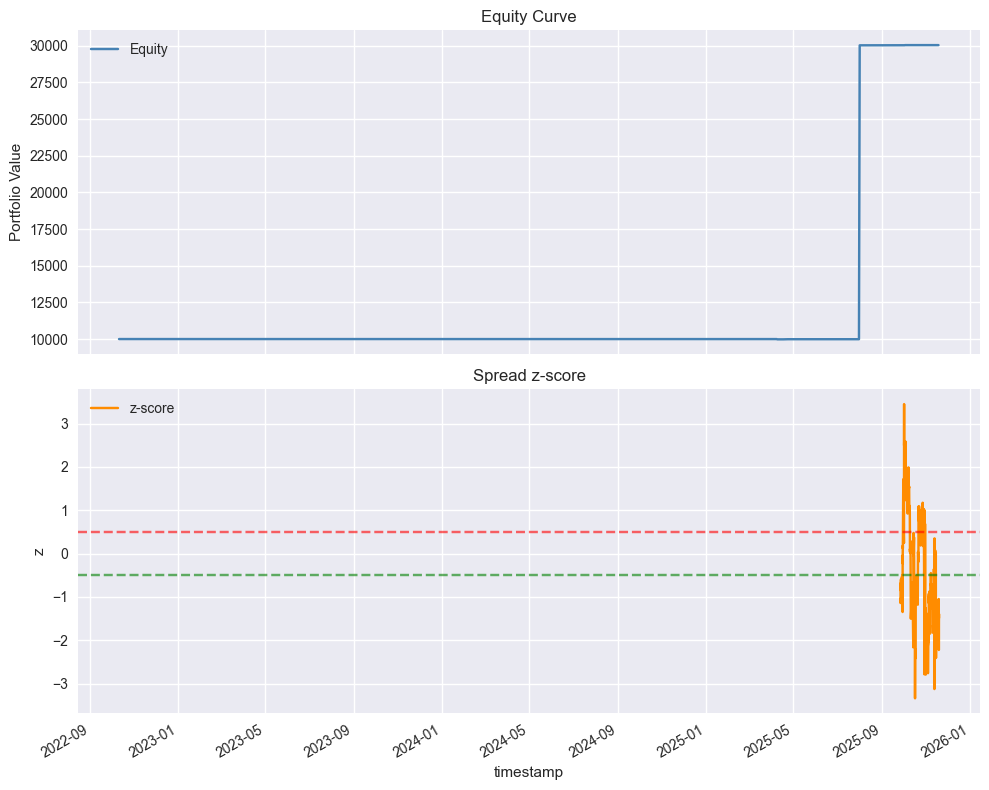

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
summary["equity_curve"].plot(ax=axes[0], color="steelblue", label="Equity")
axes[0].set_title("Equity Curve")
axes[0].set_ylabel("Portfolio Value")
axes[0].legend()

spread_df = strategy._build_option_series(
    start=strategy._iso_days_ago(strategy.lookback_days),
    end=strategy._iso_days_ago(0),
    timeframe=strategy.timeframe,
)
spread_df["z_score"].plot(ax=axes[1], color="darkorange", label="z-score")
axes[1].axhline(strategy.entry_threshold, color="red", linestyle="--", alpha=0.6)
axes[1].axhline(-strategy.entry_threshold, color="green", linestyle="--", alpha=0.6)
axes[1].set_title("Spread z-score")
axes[1].set_ylabel("z")
axes[1].legend()
plt.tight_layout()

## 6. Generate live-ready signals
Hook the strategy into the multi-leg execution helper. When `auto_execute=True`, each signal becomes a debit/credit payload. Here we keep it manual so you can inspect the legs first.

In [16]:
multi_leg = MultiLegExecutionHelper(execution_handler=None)
strategy.auto_execute = False
signals = strategy.generate_signal()
print("Generated signals:")
for leg in signals:
    print(leg)

payload = multi_leg.build_payload(signals, net_price_type="debit")
print("\nPayload ready for execution handler:")
print(json.dumps(payload, indent=2))

Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Generated signals:
{'asset_type': 'option', 'underlying': 'V', 'symbol': 'V', 'option_type': 'call', 'strike': 334.0669272766113, 'expiration': '2025-12-19', 'action': 'buy', 'qty': 1, 'limit_price': 5.346786547481912, 'type': 'limit', 'time_in_force': 'day'}
{'asset_type': 'option', 'underlying': 'MS', 'symbol': 'MS', 'option_type': 'call', 'strike': 166.1095245666504, 'expiration': '2025-12-19', 'action': 'sell', 'qty': 2, 'limit_price': 4.038152383995552, 'type': 'limit', 'time_in_force': 'day'}

Payload ready for execution handler:
{
  "legs": [
    {
      "action": "buy",
      "qty": 1,
      "asset_type": "option",
      "time_in_force": "day",
      "order_type": "limit",
      "limit_price": 5.346786547481912,
      "underlying": "V",
      "symbol": "V",
  

## 7. Next steps
1. Flip `NotebookDataHandler(use_alpaca=True)` by exporting Alpaca keys in `.env` to stream real quotes.\n2. Schedule the backtest to refresh candidate pairs nightly and log performance deltas.\n3. When comfortable, set `strategy.auto_execute = True` *after* swapping `execution_handler` for the real `ExecutionHandler` so signals route to Alpaca.